# Nested sampling

In [2]:
#!pip install dynesty

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.special import logsumexp
from scipy.stats import beta
import pickle

from dynesty import NestedSampler, DynamicNestedSampler

In [2]:
import dynesty
print("dynesty version:", dynesty.__version__)

dynesty version: 3.0.0


In [3]:
FONTSIZE=16
LABELSIZE=0.9*FONTSIZE
LINEWIDTH=2.0
FIGWIDTH=8
ASPECT_RATIO=4/3

plt.rcParams['axes.labelsize'] = FONTSIZE
plt.rcParams['axes.linewidth'] = LINEWIDTH
plt.rcParams['axes.titlesize'] = 1.1*FONTSIZE
plt.rcParams['figure.figsize'] = [FIGWIDTH, FIGWIDTH/ASPECT_RATIO]
plt.rcParams['figure.labelsize'] = FONTSIZE
plt.rcParams['figure.titlesize'] = 1.1*FONTSIZE
plt.rcParams['legend.fancybox'] = False
plt.rcParams['legend.framealpha'] = 1.0
plt.rcParams['legend.fontsize'] = LABELSIZE
plt.rcParams['legend.title_fontsize'] = LABELSIZE
plt.rcParams['patch.linewidth'] = LINEWIDTH
plt.rcParams['lines.linewidth'] = LINEWIDTH
plt.rcParams['xtick.labelsize'] = LABELSIZE
plt.rcParams['ytick.labelsize'] = LABELSIZE
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['figure.autolayout'] = True

plt.rcParams['patch.edgecolor'] = 'black'

In [4]:
DATA_PATH = "../GRBs/GRB_data.txt"
arr = np.loadtxt(DATA_PATH, skiprows=1)
logT90 = arr[:,0]
sigma_logT90 = arr[:,1]

## Single seed

In [16]:
%%time

# helper: log-density per mixture con k componenti
def log_likelihood_k(logT90, weights, mus, sigmas, sigma_logT90=0.0):
    # weights: array shape (k,), mus: (k,), sigmas: (k,) all in linear scale
    # sigma_logT90 can be scalar or array
    x = logT90
    k = len(weights)
    # compute component logN for each component and each datum
    var_components = sigmas**2
    # shape (k, N)
    logNs = []
    for i in range(k):
        var = var_components[i] + (sigma_logT90**2 if np.isscalar(sigma_logT90) else sigma_logT90**2)
        logN = -0.5*(np.log(2*np.pi*var) + ((x - mus[i])**2)/var)
        logNs.append(np.log(weights[i]) + logN)
    stacked = np.vstack(logNs)   # (k, N)
    # per-datum log-probability
    lpd = logsumexp(stacked, axis=0)
    return np.sum(lpd)

# -------------------------
# PRIORS (adattive ai dati)
# -------------------------
xmin, xmax = np.min(logT90), np.max(logT90)
xrange = xmax - xmin
margin = max(1.0, 0.5*xrange)     # margine intorno ai dati
mu_low  = xmin - margin
mu_high = xmax + margin
sd_data = max(1e-3, np.std(logT90))

# sigma bounds: più informative rispetto a [0.1,6]
sigma_min = max(0.01, sd_data * 0.05)
sigma_max = max(0.1, sd_data * 3.0)
lns_min, lns_max = np.log(sigma_min), np.log(sigma_max)

# stick-breaking prior hyperparams per i v (usiamo Beta(2,2) per evitare estremi)
beta_a, beta_b = 2.0, 2.0

# -------------------------
# H0: 2-component model
# param: [v, mu1_raw, delta, ln_s1, ln_s2]
# v -> w = v, w2 = 1-v
# mu1 ~ Uniform(mu_low, mu_high)
# delta ~ Uniform(0, mu_high - mu_low)   (positiva per ordinamento mu1 < mu2 = mu1 + delta)
# ln_s ~ Uniform(lns_min, lns_max)
# -------------------------
def prior_transform_h0(u):
    # u is vector in (0,1)^5
    v = beta.ppf(u[0], beta_a, beta_b)  # stick-breaking -> w = v
    mu1 = mu_low + u[1] * (mu_high - mu_low)
    max_delta = max(1e-3, (mu_high - mu1))   # delta cannot make mu2 > mu_high
    delta = u[2] * max_delta
    ln_s1 = lns_min + u[3] * (lns_max - lns_min)
    ln_s2 = lns_min + u[4] * (lns_max - lns_min)
    return np.array([v, mu1, delta, ln_s1, ln_s2])

def loglik_h0(theta):
    # theta returned by prior_transform_h0
    v, mu1, delta, ln_s1, ln_s2 = theta
    if not (0.0 < v < 1.0 and delta >= 0.0):
        return -np.inf
    w1 = v
    w2 = 1.0 - v
    mu2 = mu1 + delta
    sig1 = np.exp(ln_s1)
    sig2 = np.exp(ln_s2)
    # numerical safety: if any sigma out of bounds
    if sig1 <= 0 or sig2 <= 0:
        return -np.inf
    return log_likelihood_k(logT90, np.array([w1, w2]), np.array([mu1, mu2]), np.array([sig1, sig2]), sigma_logT90)

# -------------------------
# H1: 3-component model
# param u of dim 8:
# u[0],u[1] -> v1,v2 for stick-breaking
# u[2:5] -> mu_raw1, mu_raw2, mu_raw3 (independent Uniform(mu_low, mu_high)) -> ordinati => mu1<mu2<mu3
# u[5:8] -> ln_s1, ln_s2, ln_s3 uniform in [lns_min, lns_max]
# -------------------------
"""
def prior_transform_h1(u):
    v1 = beta.ppf(u[0], beta_a, beta_b)
    v2 = beta.ppf(u[1], beta_a, beta_b)
    # mus: sample 3 indep uniform and sort them to impose ordering (removes permutations)
    mus_raw = mu_low + u[2:5] * (mu_high - mu_low)
    mus_sorted = np.sort(mus_raw)   # mu1 < mu2 < mu3
    ln_s1 = lns_min + u[5] * (lns_max - lns_min)
    ln_s2 = lns_min + u[6] * (lns_max - lns_min)
    ln_s3 = lns_min + u[7] * (lns_max - lns_min)
    # Return vector in parameter-order used by log-likelihood
    return np.concatenate(([v1, v2], mus_sorted, [ln_s1, ln_s2, ln_s3]))

def loglik_h1(theta):
    # theta: [v1, v2, mu1, mu2, mu3, ln_s1, ln_s2, ln_s3]
    v1, v2 = theta[0], theta[1]
    mu1, mu2, mu3 = theta[2], theta[3], theta[4]
    ln_s1, ln_s2, ln_s3 = theta[5], theta[6], theta[7]
    # stick-breaking
    if not (0.0 < v1 < 1.0 and 0.0 < v2 < 1.0):
        return -np.inf
    w1 = v1
    w2 = (1.0 - v1) * v2
    w3 = (1.0 - v1) * (1.0 - v2)
    sigs = np.exp([ln_s1, ln_s2, ln_s3])
    if np.any(sigs <= 0.0):
        return -np.inf
    weights = np.array([w1, w2, w3])
    mus = np.array([mu1, mu2, mu3])
    return log_likelihood_k(logT90, weights, mus, sigs, sigma_logT90)
"""
# ---------- H1: 3-component with delta parametrization ----------
# param u dim = 8:
# u[0],u[1] -> v1,v2 (stick breaking)
# u[2] -> mu1 uniform
# u[3],u[4] -> delta12, delta23 
# u[5:8] -> ln_s1, ln_s2, ln_s3
def prior_transform_h1(u):
    # u length 8
    v1 = beta.ppf(u[0], beta_a, beta_b)
    v2 = beta.ppf(u[1], beta_a, beta_b)
    # mu1 uniforme su [mu_low, mu_high]
    mu1 = mu_low + u[2] * (mu_high - mu_low)

    # delta12 uniforme su [0, max_d12] con max_d12 = mu_high - mu1
    max_d12 = max(1e-8, mu_high - mu1)
    delta12 = u[3] * max_d12
    mu2 = mu1 + delta12

    # delta23 uniforme su [0, max_d23] con max_d23 = mu_high - mu2
    max_d23 = max(1e-8, mu_high - mu2)
    delta23 = u[4] * max_d23
    mu3 = mu2 + delta23

    ln_s1 = lns_min + u[5] * (lns_max - lns_min)
    ln_s2 = lns_min + u[6] * (lns_max - lns_min)
    ln_s3 = lns_min + u[7] * (lns_max - lns_min)

    return np.array([v1, v2, mu1, delta12, delta23, ln_s1, ln_s2, ln_s3])

def loglik_h1(theta):
    v1, v2 = theta[0], theta[1]
    mu1, delta12, delta23 = theta[2], theta[3], theta[4]
    ln_s1, ln_s2, ln_s3 = theta[5], theta[6], theta[7]
    if not (0.0 < v1 < 1.0 and 0.0 < v2 < 1.0 and delta12 >= 0 and delta23 >= 0):
        return -np.inf
    w1 = v1
    w2 = (1.0 - v1) * v2
    w3 = (1.0 - v1) * (1.0 - v2)
    mu2 = mu1 + delta12
    mu3 = mu2 + delta23
    sigs = np.exp([ln_s1, ln_s2, ln_s3])
    if np.any(sigs <= 0.0):
        return -np.inf
    weights = np.array([w1, w2, w3])
    mus = np.array([mu1, mu2, mu3])
    return log_likelihood_k(logT90, weights, mus, sigs, sigma_logT90)

# -------------------------
# RUN DYNESTY (H0 and H1)
# -------------------------
# settings
nlive = 1200 #600          # aumenta se vuoi più accuratezza
dlogz = 0.01  #0.5          # stopping criterion; più piccolo = più preciso (ma più lento)
print_progress = True
bound  = 'multi'
sample = 'unif'
rng = np.random.default_rng(1234)

# H0 run
print("Running dynesty for H0 (2 components)...")
"""
sampler0 = DynamicNestedSampler(loglik_h0, prior_transform_h0, ndim=5,
                                bound='multi', sample='rwalk', rstate=rng)
sampler0.run_nested(dlogz_init=dlogz, print_progress=print_progress, nlive_init=nlive)
"""
sampler0 = NestedSampler(loglik_h0, prior_transform_h0, ndim=5, nlive=nlive,
                         bound=bound, sample=sample, bootstrap=False, rstate=rng)
sampler0.run_nested(dlogz=dlogz, print_progress=print_progress)
res0 = sampler0.results
logZ0 = res0.logz[-1]
logZerr0 = res0.logzerr[-1]
print("H0 done: logZ = {:.3f} +- {:.3f}".format(logZ0, logZerr0))

# H1 run
print("Running dynesty for H1 (3 components)...")
"""
sampler1 = DynamicNestedSampler(loglik_h1, prior_transform_h1, ndim=8, 
                                bound='multi', sample='rwalk', rstate=rng)
sampler1.run_nested(dlogz_init=dlogz, print_progress=print_progress, nlive_init=nlive)
"""
sampler1 = NestedSampler(loglik_h1, prior_transform_h1, ndim=8, nlive=nlive,
                         bound=bound, sample=sample, bootstrap=False, rstate=rng)
sampler1.run_nested(dlogz=dlogz, print_progress=print_progress)

res1 = sampler1.results
logZ1 = res1.logz[-1]
logZerr1 = res1.logzerr[-1]
print("H1 done: logZ = {:.3f} +- {:.3f}".format(logZ1, logZerr1))

# BAYES FACTOR e probabilità a posteriori (prior model equiprobabili)
logBF = logZ1 - logZ0
# propaga errore approssimativamente
logBF_err = np.sqrt(logZerr0**2 + logZerr1**2)
post_prob_H1 = 1.0 / (1.0 + np.exp(-logBF))

print("logBF (H1 vs H0) = {:.3f} +- {:.3f}".format(logBF, logBF_err))
print("P(H1|D) (equiprob. apriori) = {:.4f}".format(post_prob_H1))

"""
# Salva risultati/res
with open('../chains/dynesty_results_H0.pkl', 'wb') as f:
    pickle.dump(res0, f)
with open('../chains/dynesty_results_H1.pkl', 'wb') as f:
    pickle.dump(res1, f)

print("Risultati salvati in dynesty_results_H0.pkl e dynesty_results_H1.pkl")
"""

Running dynesty for H0 (2 components)...


29778it [01:59, 250.14it/s, +1200 | bound: 73 | nc: 1 | ncall: 131068 | eff(%): 23.853 | loglstar:   -inf < -3875.744 <    inf | logz: -3895.940 +/-  0.122 | dlogz:  0.000 >  0.010]


H0 done: logZ = -3895.940 +- 0.125
Running dynesty for H1 (3 components)...


38433it [1:11:54,  8.91it/s, +1200 | bound: 1797 | nc: 1 | ncall: 4215270 | eff(%):  0.940 | loglstar:   -inf < -3869.918 <    inf | logz: -3897.328 +/-  0.134 | dlogz:  0.000 >  0.010]


H1 done: logZ = -3897.328 +- 0.138
logBF (H1 vs H0) = -1.387 +- 0.186
P(H1|D) (equiprob. apriori) = 0.1998
CPU times: user 1h 33min 4s, sys: 4min 46s, total: 1h 37min 51s
Wall time: 1h 13min 56s


'\n# Salva risultati/res\nwith open(\'../chains/dynesty_results_H0.pkl\', \'wb\') as f:\n    pickle.dump(res0, f)\nwith open(\'../chains/dynesty_results_H1.pkl\', \'wb\') as f:\n    pickle.dump(res1, f)\n\nprint("Risultati salvati in dynesty_results_H0.pkl e dynesty_results_H1.pkl")\n'

### Dinamic Nested Sampling

Risultati con 600 live points e dlogz=0.5:

    H0 done: logZ = -3896.268 +- 0.114
    H1 done: logZ = -3896.849 +- 0.126
    logBF (H1 vs H0) = -0.581 +- 0.170
    P(H1|D) (equiprob. apriori) = 0.3586

Risultati con 1200 live points e dloz=0.1: (21 min)

    H0 done: logZ = -3896.098 +- 0.136
    H1 done: logZ = -3897.439 +- 0.150
    logBF (H1 vs H0) = -1.341 +- 0.203
    P(H1|D) (equiprob. apriori) = 0.2074

Risultati con 5000 live points e dlogz=0.1: (1h 6min 10s)

    H0 done: logZ = -3896.108 +- 0.079
    H1 done: logZ = -3897.005 +- 0.082
    logBF (H1 vs H0) = -0.897 +- 0.114
    P(H1|D) (equiprob. apriori) = 0.2897

Risultati con 1200 live points e dlogz=0.01: (15min 44s)

    H0 done: logZ = -3896.027 +- 0.106
    H1 done: logZ = -3897.289 +- 0.125
    logBF (H1 vs H0) = -1.262 +- 0.164
    P(H1|D) (equiprob. apriori) = 0.2207

Risultati con 1200 live points e dlogz=0.001:  

    H0 done: logZ = -3896.043 +- 0.102
    H1 done: logZ = -3896.846 +- 0.120
    logBF (H1 vs H0) = -0.803 +- 0.157
    P(H1|D) (equiprob. apriori) = 0.3095

### Static Nested Sampling

Risultati con 1200 live points e dlogz=0.01: (15min 50s)

    H0 done: logZ = -3896.065 +- 0.126
    H1 done: logZ = -3897.183 +- 0.137
    logBF (H1 vs H0) = -1.118 +- 0.186
    P(H1|D) (equiprob. apriori) = 0.2463

#### Decision boundary (sample = 'rwalk')
Risultati con 1200 live points e dlogz=0.01 con parametri delta e bound='multi': (15min 11s)

    H0 done: logZ = -3896.065 +- 0.126
    H1 done: logZ = -3897.609 +- 0.138
    logBF (H1 vs H0) = -1.544 +- 0.187
    P(H1|D) (equiprob. apriori) = 0.1759

Risultati con 1200 live points e dlogz=0.01 con parametri delta e bound='single': (14min 22s)

    H0 done: logZ = -3896.015 +- 0.126
    H1 done: logZ = -3897.870 +- 0.138
    logBF (H1 vs H0) = -1.855 +- 0.187
    P(H1|D) (equiprob. apriori) = 0.1353

Risultati con 1200 live points e dlogz=0.01 con parametri delta e bound='none': (13min 43s)

    H0 done: logZ = -3895.762 +- 0.125
    H1 done: logZ = -3897.460 +- 0.135
    logBF (H1 vs H0) = -1.698 +- 0.184
    P(H1|D) (equiprob. apriori) = 0.1547

- _bound = 'none'_: semplice  __rejection sampling__, diventa meno efficente all'aumentare del valore L_min (constraint sulla prior mass), questo perché lo spazio dei parametri che viene accettato diventa sempre più piccolo all'aumentare del valore minimo di L.
- _bound = 'single'_: viene creata un ellissi utilizzando la media e la covarianza empirica dei live points; successivamente viene moltiplicata per un fattore (calcolato con boostrap se sample='uniform'; altrimenti il valore di default è 1.25) per contenere anche i life points rimasti fuori dall'ellissi.
- _bound = 'multi'_:
 
  - parte da un ellissi come nel caso precedente;
  - seleziona i due punti corrispondenti agli estremi opposti dell'asse maggiore dell'ellisse;
  - applica k-means utilizzando que due punti (k=2) ed assegna i punti ai due clusters
  - costruisce un ellisse per ogni cluster
  - se la diminuzione in volume supera una certa soglia, riparte dal punto 2 e divide ulteriormente i cluster; altrimenti si ferma
  
I valori sono tutti compatibili al variare di bound, quindi viene scelta la scelta più semplice ed efficente _bound='none'_, probabilmente il tempo di computazione impiegato per creare gli ellissi compensa il tempo guadagnoto nel rigettare meno punti.

#### Decision boundary (sample = 'unif')
Risultati con 1200 live points e dlogz=0.01 con parametri delta, bound='multi' e sample='unif': (1h 37min 51s)

    H0 done: logZ = -3895.940 +- 0.125
    H1 done: logZ = -3897.328 +- 0.138
    logBF (H1 vs H0) = -1.387 +- 0.186
    P(H1|D) (equiprob. apriori) = 0.1998

Con _sample='unif'_ il valore di scala per aumentare il volume dell'ellisse e calcolato con bootstap risulta troppo grande (segnale di warning dal codice), quindi è stato fissato _bootstrap=False_ con conseguente fattore di scala bloccato a 1.25.

## Multi seed

In [17]:
# ---------- helper: log-density per mixture k-componenti ----------
def log_likelihood_k(logT90, weights, mus, sigmas, sigma_logT90=0.0):
    """
    weights: array shape (k,), mus: (k,), sigmas: (k,) (linear scale)
    sigma_logT90: scalar o array (len = len(logT90))
    """
    x = logT90
    k = len(weights)
    logNs = []
    # Controlli di sicurezza sui pesi
    if np.any(np.array(weights) <= 0):
        return -np.inf
    for i in range(k):
        # var può essere scalare o array a seconda di sigma_logT90
        var = sigmas[i]**2 + (sigma_logT90**2 if np.isscalar(sigma_logT90) else sigma_logT90**2)
        # se var è array, controlla che tutti i valori siano positivi
        if np.any(var <= 0):
            return -np.inf
        # calcola il log-normale (funziona per var scalare o array broadcasting)
        logN = -0.5*(np.log(2*np.pi*var) + ((x - mus[i])**2)/var)
        logNs.append(np.log(weights[i]) + logN)
    stacked = np.vstack(logNs)   # shape (k, N)
    lpd = logsumexp(stacked, axis=0)   # per-datum log-prob
    # se vuoi, puoi verificare che non ci siano NaN/inf
    if not np.all(np.isfinite(lpd)):
        return -np.inf
    return np.sum(lpd)

# ---------- PRIORS adattive ai dati ----------
xmin, xmax = np.min(logT90), np.max(logT90)
xrange = xmax - xmin
margin = max(1.0, 0.5*xrange)
mu_low  = xmin - margin
mu_high = xmax + margin
sd_data = max(1e-3, np.std(logT90))

sigma_min = max(0.01, sd_data * 0.05)
sigma_max = max(0.1, sd_data * 3.0)
lns_min, lns_max = np.log(sigma_min), np.log(sigma_max)

beta_a, beta_b = 2.0, 2.0  # stick-breaking hyperparams

# ---------- H0: 2-component (stick-breaking + delta parametrization) ----------
def prior_transform_h0(u):
    # u.shape == (5,)
    v = beta.ppf(u[0], beta_a, beta_b)
    mu1 = mu_low + u[1] * (mu_high - mu_low)
    max_delta = max(1e-6, mu_high - mu1)
    delta = u[2] * max_delta
    ln_s1 = lns_min + u[3] * (lns_max - lns_min)
    ln_s2 = lns_min + u[4] * (lns_max - lns_min)
    return np.array([v, mu1, delta, ln_s1, ln_s2])

def loglik_h0(theta):
    v, mu1, delta, ln_s1, ln_s2 = theta
    if not (0.0 < v < 1.0 and delta >= 0.0):
        return -np.inf
    w1 = v; w2 = 1.0 - v
    mu2 = mu1 + delta
    sig1 = np.exp(ln_s1); sig2 = np.exp(ln_s2)
    if sig1 <= 0 or sig2 <= 0:
        return -np.inf
    return log_likelihood_k(logT90, np.array([w1, w2]), np.array([mu1, mu2]), np.array([sig1, sig2]), sigma_logT90)


"""
s0 = sd_data if sd_data > 0 else 1.0  # scale for exponential prior on deltas (tunable)

def prior_transform_h1_delta(u):
    # u length 8
    v1 = beta.ppf(u[0], beta_a, beta_b)
    v2 = beta.ppf(u[1], beta_a, beta_b)
    mu1 = mu_low + u[2] * (mu_high - mu_low)
    # delta12: truncated exponential on [0, max_d12]
    max_d12 = max(1e-8, mu_high - mu1)
    if s0 <= 0:
        delta12 = u[3] * max_d12
    else:
        trunc_norm = 1.0 - np.exp(-max_d12 / s0)
        delta12 = -s0 * np.log(1.0 - u[3] * trunc_norm)
    mu2 = mu1 + delta12
    max_d23 = max(1e-8, mu_high - mu2)
    if s0 <= 0:
        delta23 = u[4] * max_d23
    else:
        trunc_norm2 = 1.0 - np.exp(-max_d23 / s0)
        delta23 = -s0 * np.log(1.0 - u[4] * trunc_norm2)
    mu3 = mu2 + delta23
    ln_s1 = lns_min + u[5] * (lns_max - lns_min)
    ln_s2 = lns_min + u[6] * (lns_max - lns_min)
    ln_s3 = lns_min + u[7] * (lns_max - lns_min)
    return np.array([v1, v2, mu1, delta12, delta23, ln_s1, ln_s2, ln_s3])
"""

# ---------- H1: 3-component with delta parametrization ----------
# param u dim = 8:
# u[0],u[1] -> v1,v2 (stick breaking)
# u[2] -> mu1 uniform
# u[3],u[4] -> delta12, delta23 
# u[5:8] -> ln_s1, ln_s2, ln_s3
def prior_transform_h1_delta(u):
    # u length 8
    v1 = beta.ppf(u[0], beta_a, beta_b)
    v2 = beta.ppf(u[1], beta_a, beta_b)
    # mu1 uniforme su [mu_low, mu_high]
    mu1 = mu_low + u[2] * (mu_high - mu_low)

    # delta12 uniforme su [0, max_d12] con max_d12 = mu_high - mu1
    max_d12 = max(1e-8, mu_high - mu1)
    delta12 = u[3] * max_d12
    mu2 = mu1 + delta12

    # delta23 uniforme su [0, max_d23] con max_d23 = mu_high - mu2
    max_d23 = max(1e-8, mu_high - mu2)
    delta23 = u[4] * max_d23
    mu3 = mu2 + delta23

    ln_s1 = lns_min + u[5] * (lns_max - lns_min)
    ln_s2 = lns_min + u[6] * (lns_max - lns_min)
    ln_s3 = lns_min + u[7] * (lns_max - lns_min)

    return np.array([v1, v2, mu1, delta12, delta23, ln_s1, ln_s2, ln_s3])

def loglik_h1_delta(theta):
    v1, v2 = theta[0], theta[1]
    mu1, delta12, delta23 = theta[2], theta[3], theta[4]
    ln_s1, ln_s2, ln_s3 = theta[5], theta[6], theta[7]
    if not (0.0 < v1 < 1.0 and 0.0 < v2 < 1.0 and delta12 >= 0 and delta23 >= 0):
        return -np.inf
    w1 = v1
    w2 = (1.0 - v1) * v2
    w3 = (1.0 - v1) * (1.0 - v2)
    mu2 = mu1 + delta12
    mu3 = mu2 + delta23
    sigs = np.exp([ln_s1, ln_s2, ln_s3])
    if np.any(sigs <= 0.0):
        return -np.inf
    weights = np.array([w1, w2, w3])
    mus = np.array([mu1, mu2, mu3])
    return log_likelihood_k(logT90, weights, mus, sigs, sigma_logT90)

# ---------- funzione per eseguire N run e raccogliere logZ ----------
def multirun_model(model_name, n_runs=5, nlive=1200, dlogz=0.01, rng=None):
    """
    model_name: 'H0' o 'H1'
    ritorna: list_of_results (dynesty.results), logZs (np.array)
    """
    if rng is None:
        rng = np.random.default_rng(1234)
        
    results = []
    logZs = []
    for i in range(n_runs):
        if model_name == 'H0':
            #sampler = DynamicNestedSampler(loglik_h0, prior_transform_h0, ndim=5, bound='multi', sample='rwalk', rstate=rng)
            sampler = NestedSampler(loglik_h0, prior_transform_h0, ndim=5, nlive=nlive,
                                    bound='none', sample='rwalk', rstate=rng)
        elif model_name == 'H1':
            #sampler = DynamicNestedSampler(loglik_h1_delta, prior_transform_h1_delta, ndim=8, bound='multi', sample='rwalk', rstate=rng)
            sampler = NestedSampler(loglik_h1_delta, prior_transform_h1_delta, ndim=8, nlive=nlive,
                                    bound='none', sample='rwalk', rstate=rng)
        else:
            raise ValueError("model_name must be 'H0' or 'H1'")
        print(f"Run {i+1}/{n_runs} for {model_name}")
        # CHIAMATA DIRETTA con dlogz_init e nlive_init
        #sampler.run_nested(dlogz_init=dlogz, nlive_init=nlive, print_progress=True)
        sampler.run_nested(dlogz=dlogz, print_progress=True)
        res = sampler.results
        results.append(res)
        logZs.append(float(res.logz[-1]))
        print(f"  logZ = {logZs[-1]:.4f} ± {float(res.logzerr[-1]):.4f}")
    logZs = np.array(logZs)
    return results, logZs

# ---------- posterior predictive checks (PPC) ----------
def extract_posterior_samples_weighted(res, n_samples_draw=1000, rng=None):
    samples = res.samples  # shape (N, ndim)
    logwt = res.logwt    # shape (N,)
    lw = logwt - np.max(logwt)
    wt = np.exp(lw)
    wt = wt / np.sum(wt)
    idx = rng.choice(len(wt), size=n_samples_draw, replace=True, p=wt)
    return samples[idx, :]

def ppc_and_plots(resH0, resH1, n_ppc_samples=1000, n_samples_draw=1000, outdir='../figure/nested_sampling', rng=None):
    if rng is None:
        rng = np.random
    os.makedirs(outdir, exist_ok=True)
    postH0 = extract_posterior_samples_weighted(resH0, n_samples_draw=n_samples_draw, rng=rng)
    postH1 = extract_posterior_samples_weighted(resH1, n_samples_draw=n_samples_draw, rng=rng)
    N = len(logT90)

    def gen_synth_from_sample(sample, model='H0'):
        if model == 'H0':
            v, mu1, delta, ln_s1, ln_s2 = sample
            w = np.array([v, 1.0-v])
            mus = np.array([mu1, mu1+delta])
            sigs = np.exp([ln_s1, ln_s2])
        else: # H1 (delta parametrization)
            v1, v2, mu1, delta12, delta23, ln1, ln2, ln3 = sample
            w1 = v1
            w2 = (1.0 - v1) * v2
            w3 = (1.0 - v1) * (1.0 - v2)
            w = np.array([w1, w2, w3])
            mu2 = mu1 + delta12
            mu3 = mu2 + delta23
            mus = np.array([mu1, mu2, mu3])
            sigs = np.exp([ln1, ln2, ln3])
        comp = rng.choice(len(w), size=N, p=w)
        synth = np.array([rng.normal(loc=mus[c], scale=sigs[c]) for c in comp])
        return synth, w, mus, sigs

    synths_H0 = []
    synths_H1 = []
    for i in range(n_ppc_samples):
        s0, w0, m0, sg0 = gen_synth_from_sample(postH0[i], 'H0')
        s1, w1, m1, sg1 = gen_synth_from_sample(postH1[i], 'H1')
        synths_H0.append(s0)
        synths_H1.append(s1)
    
    bins = np.histogram_bin_edges(logT90, bins='auto')
    def hist_matrix(synths):
        H = []
        for s in synths:
            h, _ = np.histogram(s, bins=bins, density=True)
            H.append(h)
        return np.vstack(H)
    H0_mat = hist_matrix(synths_H0)
    H1_mat = hist_matrix(synths_H1)
    lower = 5; upper = 95; med = 50
    H0_lower = np.percentile(H0_mat, lower, axis=0)
    H0_med   = np.percentile(H0_mat, med, axis=0)
    H0_upper = np.percentile(H0_mat, upper, axis=0)
    H1_lower = np.percentile(H1_mat, lower, axis=0)
    H1_med   = np.percentile(H1_mat, med, axis=0)
    H1_upper = np.percentile(H1_mat, upper, axis=0)
    bin_centers = 0.5*(bins[:-1] + bins[1:])
    plt.figure(figsize=(8,5))
    plt.fill_between(bin_centers, H0_lower, H0_upper, alpha=0.25, label='H0 95% PPC band')
    plt.plot(bin_centers, H0_med, linestyle='--', label='H0 median PPC')
    plt.fill_between(bin_centers, H1_lower, H1_upper, alpha=0.25, label='H1 95% PPC band')
    plt.plot(bin_centers, H1_med, linestyle='-.', label='H1 median PPC')
    hist_obs, _ = np.histogram(logT90, bins=bins, density=True)
    plt.plot(bin_centers, hist_obs, 'k-', lw=1.5, label='observed (density)')
    plt.xlabel('log T90'); plt.ylabel('density'); plt.legend()
    plt.title('Posterior Predictive Checks (H0 vs H1)')
    plt.tight_layout()
    fname = os.path.join(outdir, 'ppc_hist.png')
    plt.savefig(fname, dpi=200)
    plt.close()
    print(f"PPC histogram salvata in {fname}")

    # mixture mean densities
    post_mean0 = np.mean(postH0, axis=0)
    v, mu1, delta, ln1, ln2 = post_mean0
    w0 = np.array([v, 1.0-v]); mus0 = np.array([mu1, mu1+delta]); sigs0 = np.exp([ln1, ln2])
    xs = np.linspace(mu_low, mu_high, 400)
    dens0 = np.zeros_like(xs)
    for i in range(2):
        dens0 += w0[i] * (1/ (np.sqrt(2*np.pi)*sigs0[i])) * np.exp(-0.5*((xs-mus0[i])**2)/(sigs0[i]**2))
    post_mean1 = np.mean(postH1, axis=0)
    v1, v2, mu1, d12, d23, ln1, ln2, ln3 = post_mean1
    w1 = v1; w2 = (1.0 - v1)*v2; w3 = (1.0 - v1)*(1.0 - v2)
    mus1 = np.array([mu1, mu1+d12, mu1+d12+d23]); sigs1 = np.exp([ln1, ln2, ln3])
    dens1 = np.zeros_like(xs)
    for i in range(3):
        dens1 += [w1, w2, w3][i] * (1/ (np.sqrt(2*np.pi)*sigs1[i])) * np.exp(-0.5*((xs-mus1[i])**2)/(sigs1[i]**2))
    plt.figure(figsize=(8,5))
    plt.plot(xs, dens0, label='H0 mixture mean')
    plt.plot(xs, dens1, label='H1 mixture mean')
    plt.hist(logT90, bins=50, density=True, alpha=0.25, label='data hist')
    plt.xlabel('log T90'); plt.ylabel('density'); plt.legend()
    plt.title('Mixture densities (posterior mean params)')
    fname2 = os.path.join(outdir, 'mixture_mean_densities.png')
    plt.tight_layout()
    plt.savefig(fname2, dpi=200)
    plt.close()
    print(f"Mixture density plot salvato in {fname2}")

In [18]:
%%time
LOAD = False

fn0 = '../chains/dynesty_multirun_H0_static_bound_none.pkl'
fn1 = '../chains/dynesty_multirun_H1_static_bound_none.pkl'

if LOAD == 0:
    # ---------- ESECUZIONE: multirun H0 e H1, poi PPC ----------
    n_runs = 5
    nlive = 1200
    dlogz = 0.01
    seed = 1234

    rng = np.random.default_rng(seed)
    res_list_H0, logZs_H0 = multirun_model('H0', n_runs=n_runs, nlive=nlive, dlogz=dlogz, rng=rng)
    
    rng = np.random.default_rng(seed) #resetto il generatore per usare stessi valori di H0
    res_list_H1, logZs_H1 = multirun_model('H1', n_runs=n_runs, nlive=nlive, dlogz=dlogz, rng=rng)

    with open(fn0, 'wb') as f:
        pickle.dump({'results': res_list_H0, 'logZs': logZs_H0}, f)
    with open(fn1, 'wb') as f:
        pickle.dump({'results': res_list_H1, 'logZs': logZs_H1}, f)
    print("Risultati multirun salvati in ../chains/")
    
else:
    with open(fn0, 'rb') as f:
        d0 = pickle.load(f)
    with open(fn1, 'rb') as f:
        d1 = pickle.load(f)
    
    res_list_H0, logZs_H0 = d0['results'], np.array(d0['logZs'])
    res_list_H1, logZs_H1 = d1['results'], np.array(d1['logZs'])

Run 1/5 for H0


29570it [04:38, 106.12it/s, +1200 | bound: 22 | nc: 1 | ncall: 677963 | eff(%):  4.547 | loglstar:   -inf < -3875.739 <    inf | logz: -3895.762 +/-  0.121 | dlogz:  0.000 >  0.010]


  logZ = -3895.7619 ± 0.1248
Run 2/5 for H0


29759it [04:42, 105.41it/s, +1200 | bound: 22 | nc: 1 | ncall: 679633 | eff(%):  4.563 | loglstar:   -inf < -3875.744 <    inf | logz: -3895.924 +/-  0.122 | dlogz:  0.000 >  0.010]


  logZ = -3895.9237 ± 0.1253
Run 3/5 for H0


...

  logZ = -3897.2924 ± 0.1387
Run 4/5 for H1


38502it [14:53, 43.08it/s, +1200 | bound: 29 | nc: 1 | ncall: 1000403 | eff(%):  3.973 | loglstar:   -inf < -3870.055 <    inf | logz: -3897.523 +/-  0.135 | dlogz:  0.000 >  0.010]


  logZ = -3897.5233 ± 0.1379
Run 5/5 for H1


38214it [16:09, 39.41it/s, +1200 | bound: 29 | nc: 1 | ncall: 993290 | eff(%):  3.973 | loglstar:   -inf < -3869.814 <    inf | logz: -3897.042 +/-  0.135 | dlogz:  0.000 >  0.010]


  logZ = -3897.0421 ± 0.1373
Risultati multirun salvati in ../chains/
CPU times: user 1h 27min 24s, sys: 23.4 s, total: 1h 27min 48s
Wall time: 1h 27min 23s


In [19]:
# Z0, Z1 arrays; res_list_H0/1 are dynesty results lists
Z0 = np.array(logZs_H0)   # dimension n
Z1 = np.array(logZs_H1)
n = len(Z0)

# internal variances (sigma^2) from dynesty logzerr
err0 = np.array([float(r.logzerr[-1]) for r in res_list_H0])
err1 = np.array([float(r.logzerr[-1]) for r in res_list_H1])
mean_internal_var0 = np.mean(err0**2)
mean_internal_var1 = np.mean(err1**2)

# between-run sample variance (ddof=1)
var_between0 = np.var(Z0, ddof=1)
var_between1 = np.var(Z1, ddof=1)

# SE on the means
se_mean_Z0 = np.sqrt((var_between0 + mean_internal_var0) / n)
se_mean_Z1 = np.sqrt((var_between1 + mean_internal_var1) / n)

print("Z0 mean = {:.4f} ± {:.4f} (SE)".format(Z0.mean(), se_mean_Z0))
print("Z1 mean = {:.4f} ± {:.4f} (SE)".format(Z1.mean(), se_mean_Z1))

# paired diffs
diffs = Z1 - Z0                 # d_i
var_between_d = np.var(diffs, ddof=1)
# internal variance per differenza = err1^2 + err0^2
mean_internal_var_d = np.mean(err1**2 + err0**2)
se_mean_diff = np.sqrt((var_between_d + mean_internal_var_d) / n)

mean_diff = diffs.mean()
print("mean logBF (paired) = {:.4f} ± {:.4f} (SE)".format(mean_diff, se_mean_diff))

post_prob_H1 = 1.0 / (1.0 + np.exp(-mean_diff))

print(f"P(H1|D) = {post_prob_H1:.4f}")

#ppc_and_plots(res_list_H0[0], res_list_H1[0], n_ppc_samples=300, outdir='../figures')

Z0 mean = -3896.0538 ± 0.1595 (SE)
Z1 mean = -3897.3949 ± 0.1186 (SE)
mean logBF (paired) = -1.3411 ± 0.2559 (SE)
P(H1|D) = 0.2073


### Dinamic nested sampling
Risultati nlive=1200, dloz=0.01, n_runs=5:

    Z0 mean = -3896.0326 ± 0.1090 (SE)
    Z1 mean = -3896.5196 ± 0.1986 (SE)
    mean logBF (paired) = -0.4871 ± 0.2131 (SE)
    P(H1|D) = 0.3806

### Static nested sampling
Risultati nlive=1200, dloz=0.01, n_runs=5, bound='multi': (53 min only H1)

    Z0 mean = -3896.0102 ± 0.0604 (SE)
    Z1 mean = -3897.7560 ± 0.1144 (SE)
    mean logBF (paired) = -1.7458 ± 0.1199 (SE)
    P(H1|D) = 0.1486

Risultati nlive=1200, dloz=0.01, n_runs=5, bound='none': (1h 27min 48s)

    Z0 mean = -3896.0538 ± 0.1595 (SE)
    Z1 mean = -3897.3949 ± 0.1186 (SE)
    mean logBF (paired) = -1.3411 ± 0.2559 (SE)
    P(H1|D) = 0.2073

In [9]:
# Errore sul calcolo delle Z vs errore sulla variazione dei seed
# H0
print(np.sqrt(mean_internal_var0))
print(np.sqrt(var_between0))
print(se_mean_Z0*np.sqrt(n)) #combinazione dei due errori (supponendo indipendenza)

# H1
print('\n')
print(np.sqrt(mean_internal_var1))
print(np.sqrt(var_between1))
print(se_mean_Z1*np.sqrt(n))

# BF
print('\n')
print(np.sqrt(var_between_d))
print(np.sqrt(mean_internal_var_d))
print(se_mean_diff*np.sqrt(n))

0.10612092327298271
0.2194209798859189
0.2437359570732376


0.12137840027492562
0.427266188491569
0.4441723898233805


0.44836109032684374
0.16122768499736748
0.4764682924693799


In [11]:
rng = np.random.default_rng(1234)
ppc_and_plots(res_list_H0[0], res_list_H1[0], n_ppc_samples=1000, outdir='../figure/nested_sampling', rng=rng)

PPC histogram salvata in ../figure/nested_sampling/ppc_hist.png
Mixture density plot salvato in ../figure/nested_sampling/mixture_mean_densities.png


In [21]:
from dynesty import utils as dyfunc

# Merge into a single run.
res_merged_H0 = dyfunc.merge_runs(res_list_H0)
res_merged_H1 = dyfunc.merge_runs(res_list_H1)

Merge: 5/5     

In [23]:
logZ0 = res_merged_H0.logz[-1]
logZerr0 = res_merged_H0.logzerr[-1]
print("H0 done: logZ = {:.3f} +- {:.3f}".format(logZ0, logZerr0))

logZ1 = res_merged_H1.logz[-1]
logZerr1 = res_merged_H1.logzerr[-1]
print("H1 done: logZ = {:.3f} +- {:.3f}".format(logZ1, logZerr1))

# BAYES FACTOR e probabilità a posteriori (prior model equiprobabili)
logBF = logZ1 - logZ0
# propaga errore approssimativamente
logBF_err = np.sqrt(logZerr0**2 + logZerr1**2)
post_prob_H1 = 1.0 / (1.0 + np.exp(-logBF))

print("logBF (H1 vs H0) = {:.3f} +- {:.3f}".format(logBF, logBF_err))
print("P(H1|D) (equiprob. apriori) = {:.4f}".format(post_prob_H1))

H0 done: logZ = -3896.060 +- 0.057
H1 done: logZ = -3897.414 +- 0.062
logBF (H1 vs H0) = -1.354 +- 0.084
P(H1|D) (equiprob. apriori) = 0.2052


In [31]:
# Carico i risultati del MCMC per confrontarli con quelli del nested sampling
samples = np.loadtxt('../chains/chain_final.txt')
samples.shape

(4349, 5)

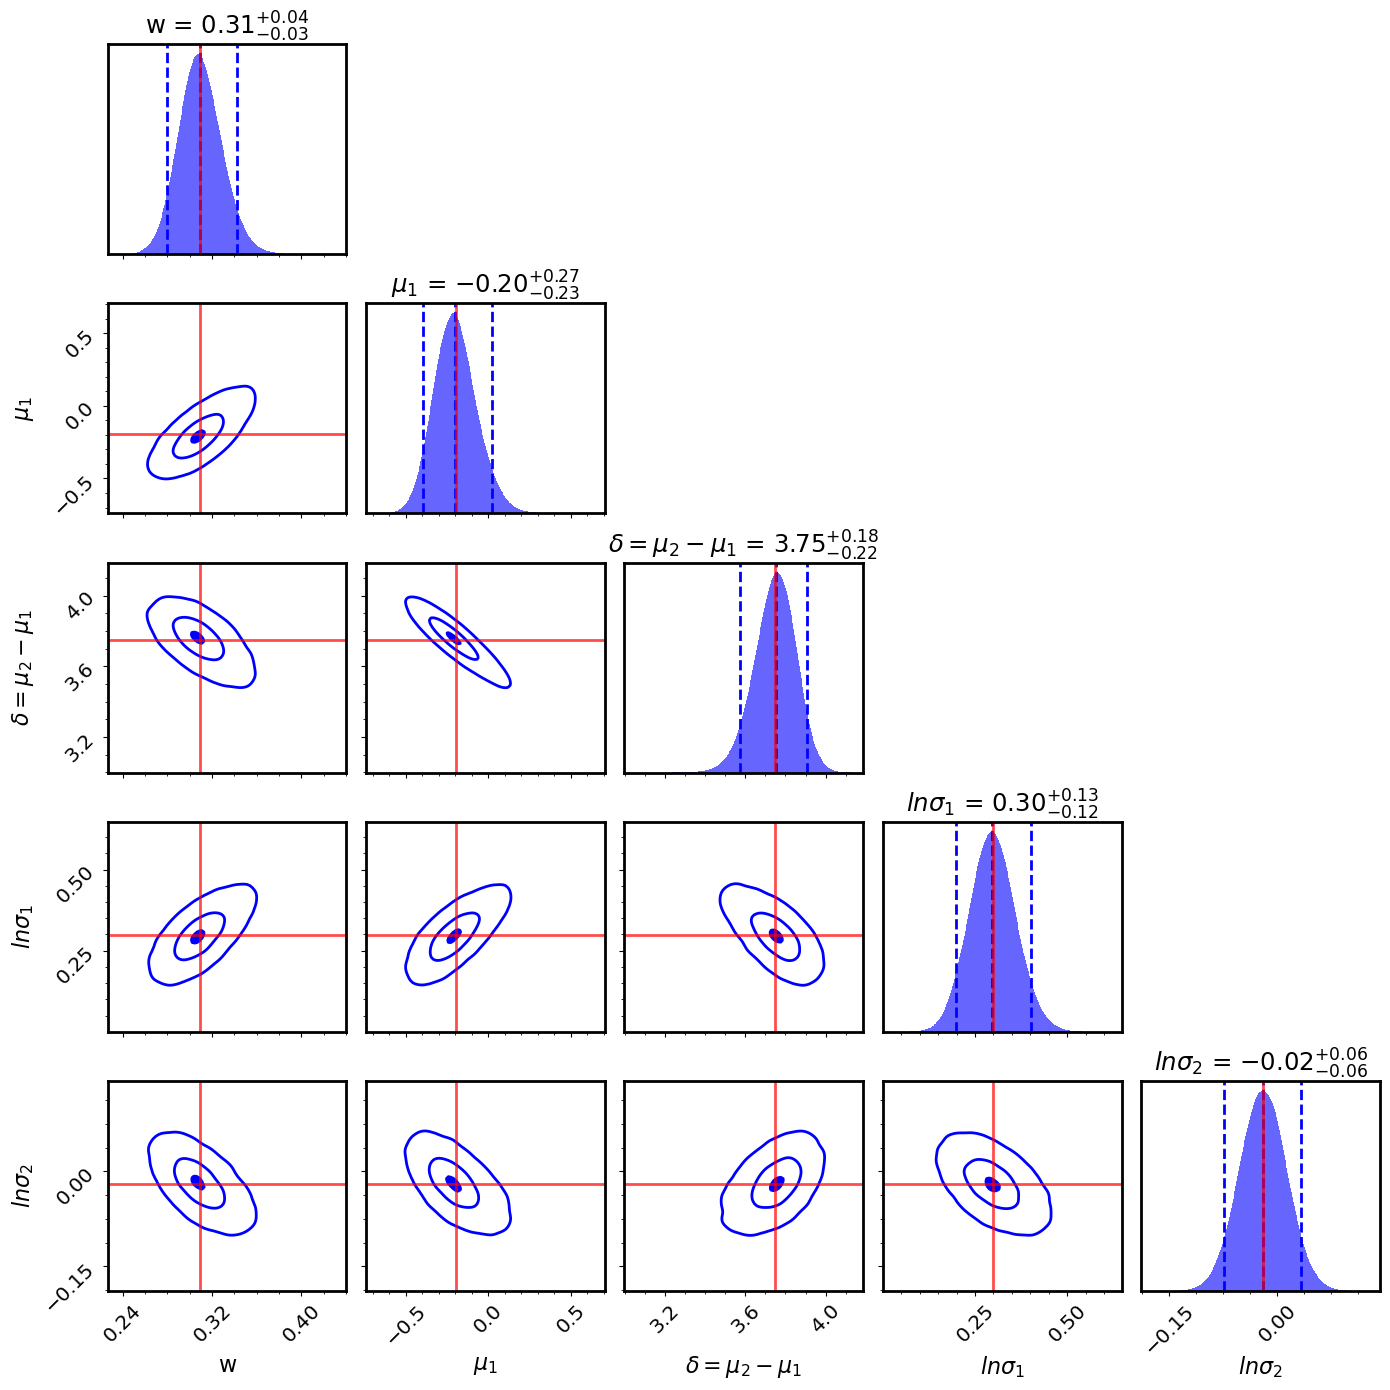

In [51]:
ndim = 5

# crea figura 5x5
fig, axes = plt.subplots(ndim, ndim, figsize=(14, 14))
axes = axes.reshape((ndim, ndim))

# opzioni comuni
#span = [(-4.5, 4.5) for _ in range(ndim)]
#span = 0.9*np.ones(ndim)
truths = np.mean(samples,axis=0)
labels = ['w', '$\mu_1$', '$\delta = \mu_2 - \mu_1$', '$ln\sigma_1$', '$ln\sigma_2$']

# disegna soltanto res1 (o merged_H1 se usi l'array unito)
fg, ax = dyplot.cornerplot(
    res_merged_H0,        
    color='blue',
    truths=truths,
    truth_color='red',
    show_titles=True,
    max_n_ticks=3,
    quantiles=[0.05,0.5,0.95],
    quantiles_2d=[0.05,0.5,0.95],
    labels = labels,
    fig=(fig, axes)         
)

# aggiusta spaziatura e mostra
plt.subplots_adjust(wspace=0.03, hspace=0.03)
plt.savefig('../figure/nested_sampling/cornerplot_ns_H0.png', bbox_inches='tight', dpi=300)
plt.savefig('../figure/nested_sampling/cornerplot_ns_H0.pdf', bbox_inches='tight', dpi=300)
plt.show()

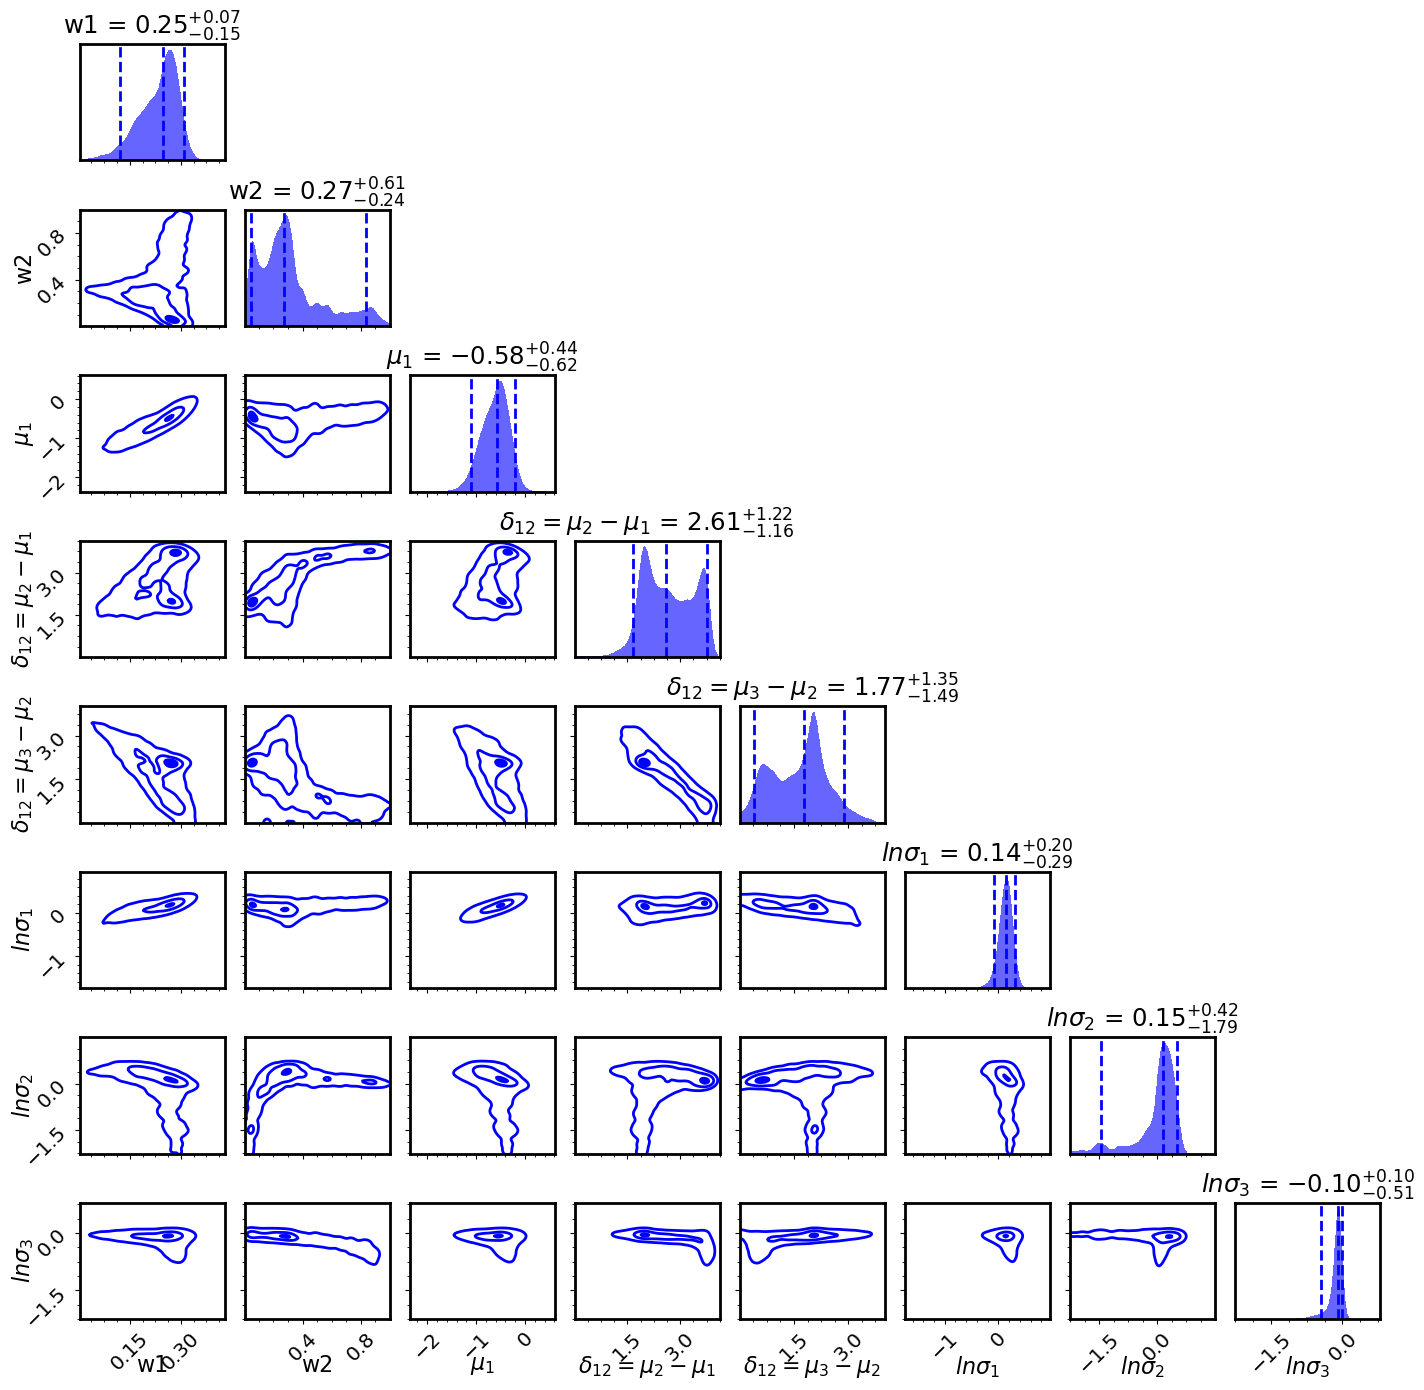

In [52]:
ndim = 8

# crea figura 5x5
fig, axes = plt.subplots(ndim, ndim, figsize=(14, 14))
axes = axes.reshape((ndim, ndim))

# opzioni comuni
#truths = np.mean(samples,axis=0)
labels = ['w1', 'w2', '$\mu_1$', '$\delta_{12} = \mu_2 - \mu_1$', '$\delta_{12} = \mu_3 - \mu_2$', 
          '$ln\sigma_1$', '$ln\sigma_2$', '$ln\sigma_3$']

# disegna soltanto res1 (o merged_H1 se usi l'array unito)
fg, ax = dyplot.cornerplot(
    res_merged_H1,        
    color='blue',
#    truths=truths,
#    truth_color='red',
    show_titles=True,
    max_n_ticks=3,
    quantiles=[0.05,0.5,0.95],
    quantiles_2d=[0.05,0.5,0.95],
    labels=labels,
    fig=(fig, axes)         
)

# aggiusta spaziatura e mostra
plt.subplots_adjust(wspace=0.03, hspace=0.03)
plt.savefig('../figure/nested_sampling/cornerplot_ns_H1.png', bbox_inches='tight', dpi=300)
plt.savefig('../figure/nested_sampling/cornerplot_ns_H1.pdf', bbox_inches='tight', dpi=300)
plt.show()